# OPENAI CLIP

In [18]:
import os
import cv2
import gc
import numpy as np
import pandas as pd
import itertools
from tqdm.autonotebook import tqdm
import albumentations as A

import torch
from torch import nn
import torch.nn.functional as F
import timm
from transformers import DistilBertModel, DistilBertConfig, DistilBertTokenizer
import matplotlib.pyplot as plt

## Config

In [2]:
class Config:
    debug = False
    image_path = "datasets/flicker8k/Image"
    captions_path = "datasets/flicker8k"

    batch_size = 32
    num_workers = 4
    head_lr = 1e-3
    image_encoder_lr = 1e-4
    text_encoder_lr = 1e-5
    weight_decay = 1e-3
    patience = 1
    factor = 0.8
    epochs = 4
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model_name = 'resnet50.a1_in1k'
    image_embedding = 2048
    text_encoder_model = "distilbert-base-uncased"
    text_embedding = 768
    text_tokenizer = "distilbert-base-uncased"
    max_length = 200

    pretrained = True # for both image encoder and text encoder
    trainable = True # for both image encoder and text encoder
    temperature = 1.0

    # image size
    size = 224

    # for projection head; used for both image and text encoders
    num_projection_layers = 1
    projection_dim = 256 
    dropout = 0.1

## Utils

In [3]:
class AvgMeter:
    def __init__(self, name="Metric"):
        self.name = name
        self.reset()

    def reset(self):
        self.avg, self.sum, self.count = [0] * 3

    def update(self, val, count=1):
        self.count += count
        self.sum += val * count
        self.avg = self.sum / self.count

    def __repr__(self):
        text = f"{self.name}: {self.avg:.4f}"
        return text

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

## Dataset

In [4]:
class CLIPDataset(torch.utils.data.Dataset):
    def __init__(self, image_filenames, captions, ids, tokenizer, transforms):
        self.image_filenames = image_filenames
        self.captions = list(captions)
        self.ids = ids
        self.encoded_captions = tokenizer(
            list(captions), padding=True, max_length=Config.max_length
        )
        self.transforms = transforms

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(values[idx]) for key, values in self.encoded_captions.items()
        }

        img_path = f"{Config.image_path}/{self.image_filenames[idx]}"

        if not os.path.exists(img_path):
            print(f"错误: 文件不存在 - {img_path}")
            raise FileNotFoundError(f"文件不存在: {img_path}")
        if os.path.getsize(img_path) == 0:
            print(f"错误: 文件为空 - {img_path}")
            raise ValueError(f"文件为空: {img_path}")
        image = cv2.imread(img_path)
        if image is None:
            print(f"错误: cv2.imread返回None - {img_path}")
            print(f"  文件大小: {os.path.getsize(img_path)} bytes")
            print(f"  文件扩展名: {os.path.splitext(img_path)[1]}")
            raise ValueError(f"无法读取图像: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transforms(image=image)['image']

        item["image"] = torch.tensor(image).permute(2, 0, 1).float()
        item["caption"] = self.captions[idx]
        item["id"] = torch.tensor(self.ids[idx], dtype=torch.long)

        return item
    
    def __len__(self):
        return len(self.captions)
    
def get_transforms(mode="train"):
    if mode == "train":
        return A.Compose(
            [
                A.Resize(Config.size, Config.size, always_apply=True),
                A.Normalize(max_pixel_value=255.0, always_apply=True),
            ]
        )
    else:
        return A.Compose(
            [
                A.Resize(Config.size, Config.size, always_apply=True),
                A.Normalize(max_pixel_value=255.0, always_apply=True),
            ]
        )

## Image Encoder

In [5]:
class ImageEncoder(nn.Module):
    def __init__(self, model_name=Config.model_name, pretrained=Config.pretrained, trainable=Config.trainable):
        super().__init__()
        # self.model = AutoModelForImageClassification.from_pretrained(
        #     model_name,
        #     local_files_only=True
        # )

        self.model = timm.create_model(
            'resnet50.a1_in1k',
            pretrained=False,
            checkpoint_path="resnet50.a1_in1k/model.safetensors",
            # num_classes=0,
            global_pool="avg"
        )

        self.model.fc = nn.Identity()

        for p in self.model.parameters():
            p.requires_grad = trainable
    
    def forward(self, x):
        return self.model(x)

## Text Encoder

In [6]:
class TextEncoder(nn.Module):
    def __init__(self, model_name=Config.text_encoder_model, pretrained=Config.pretrained, trainable=Config.trainable):
        super().__init__()
        if pretrained:
            self.model = DistilBertModel.from_pretrained(model_name)
        else:
            self.model = DistilBertModel(config=DistilBertConfig())
        
        for p in self.model.parameters():
            p.requires_grad = trainable

        # Use the CLS token hidden representation as the sentence's embedding
        self.target_token_idx = 0

    def forward(self, input_ids, attention_mask):
        output = self.model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = output.last_hidden_state
        return last_hidden_state[:, self.target_token_idx, :]

## Projection Head

In [7]:
class ProjectionHead(nn.Module):
    def __init__(self,
                 embedding_dim, 
                 projection_dim=Config.projection_dim,
                 dropout=Config.dropout):
        super().__init__()
        self.projection = nn.Linear(embedding_dim, projection_dim)
        self.gelu = nn.GELU()
        self.fc = nn.Linear(projection_dim, projection_dim)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(projection_dim)
    
    def forward(self, x):
        projected = self.projection(x)
        x = self.gelu(projected)
        x = self.fc(x)
        x = self.dropout(x)
        x = x + projected
        x = self.layer_norm(x)
        return x

In [8]:
class CLIPModel(nn.Module):
    def __init__(self,
                 temperature=Config.temperature,
                 image_embedding=Config.image_embedding,
                 text_embedding=Config.text_embedding):
        super().__init__()
        self.image_encoder = ImageEncoder()
        self.text_encoder = TextEncoder()
        self.image_projection = ProjectionHead(embedding_dim=image_embedding)
        self.text_projection = ProjectionHead(embedding_dim=text_embedding)
        self.temperature = temperature
    
    def forward(self, batch):
        image_features = self.image_encoder(batch["image"])
        text_features = self.text_encoder(
            input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]
        )

        image_embeddings = self.image_projection(image_features)
        text_embeddings = self.text_projection(text_features)

        image_embeddings = F.normalize(image_embeddings, p=2, dim=-1)
        text_embeddings = F.normalize(text_embeddings, p=2, dim=-1)

        logits = (text_embeddings @ image_embeddings.T) / self.temperature

        ids = batch["id"]
        if ids.ndim > 1:
            ids = ids.view(ids.size(0))
        # True if ids in row is the same in that of column
        positive_mask = ids.unsqueeze(1) == ids.unsqueeze(0)
        positive_counts = positive_mask.sum(dim=-1, keepdim=True)
        targets = positive_mask.float() / positive_counts.clamp_min(1.0)

        # Bidirection: text match images, then image match texts
        # Note that these two are not the same since softmax is on different dim
        texts_loss = cross_entropy(logits, targets, reduction='none')
        images_loss = cross_entropy(logits.T, targets.T, reduction='none')
        loss = (images_loss + texts_loss) / 2.0
        return loss.mean()
    
def cross_entropy(preds, targets, reduction='none'):
    log_softmax = nn.LogSoftmax(dim=-1)
    loss = (-targets * log_softmax(preds)).sum(1)
    if reduction == "none":
        return loss
    elif reduction == "mean":
        return loss.mean()
        

In [9]:
batch_size = 4
dim = 256
embeddings = torch.randn(batch_size, dim)
out = embeddings @ embeddings.T
print(F.softmax(out, dim=-1))

tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])


## Train

In [10]:
def make_train_valid_dfs():
    dataframe = pd.read_csv(f"{Config.captions_path}/captions.csv")
    max_id = dataframe["id"].max() + 1 if not Config.debug else 100
    image_ids = np.arange(0, max_id)
    np.random.seed(42)
    # split valid and train set
    valid_ids = np.random.choice(
        image_ids, size=int(0.2 * len(image_ids)), replace=False
    )
    train_ids = [id_ for id_ in image_ids if id_ not in valid_ids]
    train_dataframe = dataframe[dataframe["id"].isin(train_ids)].reset_index(drop=True)
    valid_dataframe = dataframe[dataframe["id"].isin(valid_ids)].reset_index(drop=True)
    return train_dataframe, valid_dataframe

def build_loaders(dataframe, tokenizer, mode):
    transforms = get_transforms(mode=mode)
    dataset = CLIPDataset(
        dataframe["image"].values,
        dataframe["caption"].values,
        dataframe["id"].values,
        tokenizer=tokenizer,
        transforms=transforms,
    )
    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=Config.batch_size,
        num_workers=Config.num_workers,
        shuffle=True if mode == "train" else False,
    )
    return dataloader

In [11]:
def train_epoch(model, train_loader, optimizer, lr_scheduler, step):
    loss_meter = AvgMeter()
    tqdm_object = tqdm(train_loader, total=len(train_loader))
    for batch in tqdm_object:
        batch = {k: v.to(Config.device) for k, v in batch.items() if k != "caption"}
        loss = model(batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step == "batch":
            lr_scheduler.step()

        count = batch["image"].size(0)
        loss_meter.update(loss.item(), count)

        tqdm_object.set_postfix(train_loss=loss_meter.avg, lr=get_lr(optimizer))
    return loss_meter

def valid_epoch(model, valid_loader):
    loss_meter = AvgMeter()

    tqdm_object = tqdm(valid_loader, total=len(valid_loader))
    for batch in tqdm_object:
        batch = {k: v.to(Config.device) for k, v in batch.items() if k != "caption"}
        loss = model(batch)

        count = batch["image"].size(0)
        loss_meter.update(loss.item(), count)

        tqdm_object.set_postfix(valid_loss=loss_meter.avg)
    return loss_meter

def main():
    train_df, valid_df = make_train_valid_dfs()
    tokenizer = DistilBertTokenizer.from_pretrained(Config.text_tokenizer)
    train_loader = build_loaders(train_df, tokenizer, mode="train")
    valid_loader = build_loaders(valid_df, tokenizer, mode="valid")


    model = CLIPModel().to(Config.device)
    params = [
        {"params": model.image_encoder.parameters(), "lr": Config.image_encoder_lr},
        {"params": model.text_encoder.parameters(), "lr": Config.text_encoder_lr},
        {"params": itertools.chain(
            model.image_projection.parameters(), model.text_projection.parameters()
        ), "lr": Config.head_lr, "weight_decay": Config.weight_decay}
    ]
    optimizer = torch.optim.AdamW(params, weight_decay=0.)
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=Config.patience, factor=Config.factor
    )
    step = "epoch"

    best_loss = float('inf')
    for epoch in range(Config.epochs):
        print(f"Epoch: {epoch + 1}")
        model.train()
        train_loss = train_epoch(model, train_loader, optimizer, lr_scheduler, step)
        model.eval()
        with torch.no_grad():
            valid_loss = valid_epoch(model, valid_loader)
        
        if valid_loss.avg < best_loss:
            best_loss = valid_loss.avg
            torch.save(model.state_dict(), "models/best.pt")
            print("Saved Best Model!")
        
        lr_scheduler.step(valid_loss.avg)

In [12]:
main()

/tmp/ipykernel_233772/4017916100.py:47: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(Config.size, Config.size, always_apply=True),
/tmp/ipykernel_233772/4017916100.py:48: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(max_pixel_value=255.0, always_apply=True),
/home/haoyangsun/anaconda3/envs/prelim/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:2914: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/tmp/ipykernel_233772/4017916100.py:54: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(Config.size, Config.size, always_apply=True),
/tmp/ipykernel_233772/4017916100.py:55: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(max_pixel_value=255.0, always_apply=True),


Epoch: 1


100%|██████████| 253/253 [00:07<00:00, 33.11it/s, valid_loss=2.76]


Saved Best Model!
Epoch: 2


100%|██████████| 253/253 [00:09<00:00, 27.49it/s, valid_loss=2.74]


Saved Best Model!
Epoch: 3


100%|██████████| 253/253 [00:07<00:00, 32.16it/s, valid_loss=2.73]


Saved Best Model!
Epoch: 4


100%|██████████| 253/253 [00:07<00:00, 32.26it/s, valid_loss=2.72]


Saved Best Model!


## Inference

In [16]:
def get_image_embeddings(valid_df, model_path):
    tokenizer = DistilBertTokenizer.from_pretrained(Config.text_tokenizer)
    valid_loader = build_loaders(valid_df, tokenizer, mode="valid")
    
    model = CLIPModel().to(Config.device)
    model.load_state_dict(torch.load(model_path, map_location=Config.device))
    model.eval()
    
    valid_image_embeddings = []
    with torch.no_grad():
        for batch in tqdm(valid_loader):
            image_features = model.image_encoder(batch["image"].to(Config.device))
            image_embeddings = model.image_projection(image_features)
            valid_image_embeddings.append(image_embeddings)
    return model, torch.cat(valid_image_embeddings)

In [17]:
_, valid_df = make_train_valid_dfs()
model, image_embeddings = get_image_embeddings(valid_df, "models/best.pt")

/tmp/ipykernel_233772/4017916100.py:54: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(Config.size, Config.size, always_apply=True),
/tmp/ipykernel_233772/4017916100.py:55: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(max_pixel_value=255.0, always_apply=True),
/home/haoyangsun/anaconda3/envs/prelim/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:2914: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
100%|██████████| 253/253 [00:06<00:00, 41.16it/s]


## Finding Matches

In [19]:
def find_matches(model, image_embeddings, query, image_filenames, n=9):
    tokenizer = DistilBertTokenizer.from_pretrained(Config.text_tokenizer)
    encoded_query = tokenizer([query])
    batch = {
        key: torch.tensor(values).to(Config.device)
        for key, values in encoded_query.items()
    }
    with torch.no_grad():
        text_features = model.text_encoder(
            input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]
        )
        text_embeddings = model.text_projection(text_features)
    
    image_embeddings_n = F.normalize(image_embeddings, p=2, dim=-1)
    text_embeddings_n = F.normalize(text_embeddings, p=2, dim=-1)
    dot_similarity = text_embeddings_n @ image_embeddings_n.T
    
    values, indices = torch.topk(dot_similarity.squeeze(0), n * 5)
    matches = [image_filenames[idx] for idx in indices[::5]]
    
    _, axes = plt.subplots(3, 3, figsize=(10, 10))
    for match, ax in zip(matches, axes.flatten()):
        image = cv2.imread(f"{Config.image_path}/{match}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        ax.imshow(image)
        ax.axis("off")
    
    plt.show()

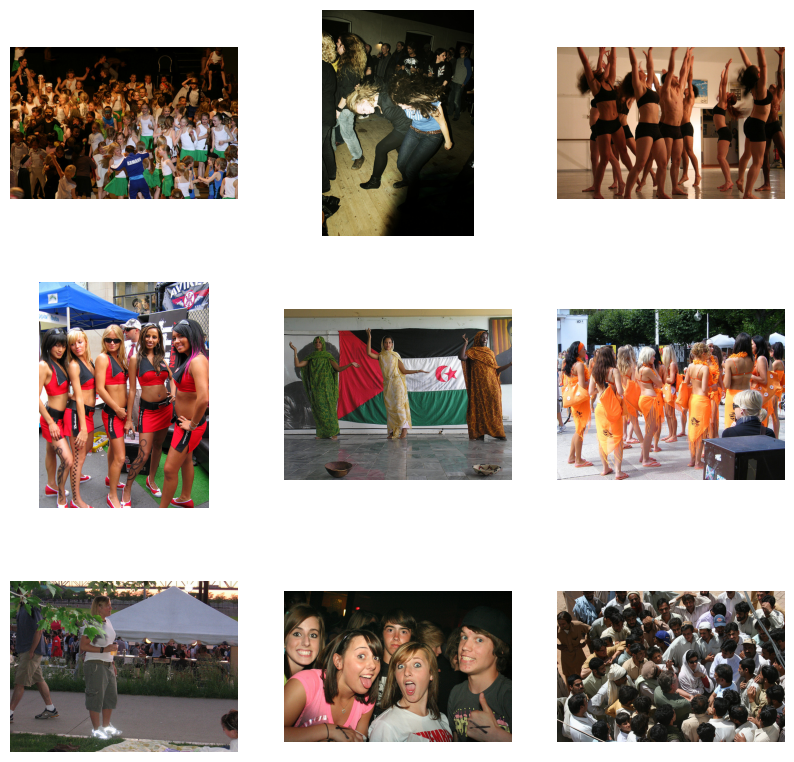

In [20]:
find_matches(model, 
             image_embeddings,
             query="a group of people dancing in a party",
             image_filenames=valid_df['image'].values,
             n=9)